# South Africa — Rival framing reference-set and scenario re-evaluation notebook

This notebook is a clean, project-style workflow for the South Africa rival-framing analysis.

It follows the same logic as the main project workflow:

1. Load Pareto-optimal policies from existing optimisation outputs.
2. Merge rival welfare framings into one combined candidate pool.
3. Build an approximate non-dominated reference set.
4. Select representative policies for the rival-framing comparison.
5. Re-run selected policies across SSP-RCP scenarios and climate ensemble members.
6. Export South Africa burden, robustness, and rival-framing comparison tables.

**Important:** this notebook does **not** run a new MOEA optimisation. It starts from existing `pareto_front_*.csv` and/or `reference_set_*.csv` files in your project `results` folder.

## 0. Setup and file locations

Run this cell first. It detects the project folders, imports JUSTICE, and sets the working directory to `JUSTICE-main`, which is needed by the model's internal file loading.

In [1]:
import os
import sys
import json
import glob
import re
import copy
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Matplotlib compatibility patch used in the main project notebook.
try:
    import matplotlib.path as _mpath

    def _fixed_path_deepcopy(self, memo):
        cls = type(self)
        verts = copy.deepcopy(self.vertices, memo)
        codes = copy.deepcopy(self.codes, memo) if self.codes is not None else None
        new = cls.__new__(cls)
        new.__init__(verts, codes)
        return new

    _mpath.Path.__deepcopy__ = _fixed_path_deepcopy
except Exception:
    pass

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    import matplotlib
    matplotlib.use("Agg")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# Detect notebook directory. In VS Code notebooks, __vsc_ipynb_file__ is usually available.
try:
    NOTEBOOK_DIR = Path(__vsc_ipynb_file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd().resolve()

# Find repo root: folder containing JUSTICE-main and config.
REPO_ROOT = NOTEBOOK_DIR
for candidate in [NOTEBOOK_DIR] + list(NOTEBOOK_DIR.parents):
    if (candidate / "JUSTICE-main").exists() and (candidate / "config").exists():
        REPO_ROOT = candidate
        break

JUSTICE_ROOT = (REPO_ROOT / "JUSTICE-main").resolve()
CONFIG_DIR = (REPO_ROOT / "config").resolve()
PROJECT_DIR = (REPO_ROOT / "A- Project G15").resolve()

RESULTS_DIR = (PROJECT_DIR / "results").resolve()
PLOTS_DIR = (PROJECT_DIR / "plots").resolve()
TABLES_DIR = (PROJECT_DIR / "tables").resolve()
for path in [RESULTS_DIR, PLOTS_DIR, TABLES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

if str(JUSTICE_ROOT) not in sys.path:
    sys.path.insert(0, str(JUSTICE_ROOT))

# JUSTICE uses relative file paths internally, so set cwd to JUSTICE-main.
os.chdir(JUSTICE_ROOT)

from justice.model import JUSTICE
from justice.util.data_loader import DataLoader
from justice.util.enumerations import Abatement, DamageFunction, Economy, WelfareFunction
from justice.util.emission_control_constraint import EmissionControlConstraint
from justice.util.model_time import TimeHorizon
from solvers.emodps.rbf import RBF

print("Notebook dir:", NOTEBOOK_DIR)
print("Repo root:", REPO_ROOT)
print("Project dir:", PROJECT_DIR)
print("JUSTICE root:", JUSTICE_ROOT)
print("Config dir:", CONFIG_DIR)
print("Results dir:", RESULTS_DIR)
print("Plots dir:", PLOTS_DIR)
print("Tables dir:", TABLES_DIR)

Notebook dir: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15
Repo root: /Users/wesselmuntendam/Model Based Decision Making/epa141a
Project dir: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15
JUSTICE root: /Users/wesselmuntendam/Model Based Decision Making/epa141a/JUSTICE-main
Config dir: /Users/wesselmuntendam/Model Based Decision Making/epa141a/config
Results dir: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results
Plots dir: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/plots
Tables dir: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/tables


## 1. Analysis settings

Use the quick settings first to test the workflow. Then change to the definitive settings.

In [2]:
ACTOR = "South Africa"
KEY_REGION = "zaf"

# Rival framing focus.
WELFARE_FRAMES = ["PRIORITARIAN", "UTILITARIAN"]
PREFERRED_WELFARE = "PRIORITARIAN"
RIVAL_WELFARE = "UTILITARIAN"

# Scenario re-evaluation settings.
# Quick test:
#   SCENARIOS_REEVAL = [2, 3]
#   N_ENSEMBLES_REEVAL = 3
#   MAX_POLICIES_TO_REEVALUATE = 2
# Definitive run:
#   SCENARIOS_REEVAL = list(range(8))
#   N_ENSEMBLES_REEVAL = 15
#   MAX_POLICIES_TO_REEVALUATE = None
RUN_REEVALUATION = True
SCENARIOS_REEVAL = list(range(8))
N_ENSEMBLES_REEVAL = 15
MAX_POLICIES_TO_REEVALUATE = None

# Policy selection settings.
POLICIES_PER_FRAME = 3
INCLUDE_LOW_CLIMATE_RISK_POLICIES = True
INCLUDE_COMPROMISE_POLICIES = True

# Temperature and RBF scaling settings from the project notebook.
MAX_TEMP, MIN_TEMP = 16.0, 0.0
MAX_DIFF, MIN_DIFF = 2.0, 0.0

# Years used for burden snapshots in the tables.
YEARS_OF_INTEREST = [2050, 2100]
COMPARE_REGIONS = ["zaf", "usa", "gbr", "fra", "rfa", "pol", "chn", "rus"]

framings = pd.DataFrame([
    {
        "framing": "South Africa justice framing",
        "model_lens": "Prioritarian welfare function + focus on zaf",
        "main_indicator": "abatement_cost_zaf / gross_economic_output_zaf",
        "political_interpretation": "Fairness as proportional burden; ambition is acceptable only with transition finance.",
    },
    {
        "framing": "Global efficiency framing",
        "model_lens": "Utilitarian welfare function",
        "main_indicator": "welfare, fraction_above_threshold",
        "political_interpretation": "Fairness as total global performance; can hide unequal regional transition burdens.",
    },
    {
        "framing": "Equal obligation framing",
        "model_lens": "Compare mitigation effort across regions",
        "main_indicator": "emission_control_rate_zaf vs developed regions",
        "political_interpretation": "Equal mitigation rates can still create unequal proportional burdens.",
    },
    {
        "framing": "High-ambition / survival framing",
        "model_lens": "Climate-risk focused evaluation",
        "main_indicator": "fraction_above_threshold, global_temperature, damage_burden_zaf",
        "political_interpretation": "Urgency matters, but ambition must be financed to be politically feasible.",
    },
])

display(framings)
framings.to_csv(TABLES_DIR / "rival_framings_model_operationalisation.csv", index=False)
framings.to_latex(TABLES_DIR / "rival_framings_model_operationalisation.tex", index=False)
print("Saved rival framing operationalisation tables.")

,framing,model_lens,main_indicator,political_interpretation
0,South Africa justice framing,Prioritarian welfare function + focus on zaf,abatement_cost_zaf / gross_economic_output_zaf,Fairness as proportional burden; ambition is a...
1,Global efficiency framing,Utilitarian welfare function,"welfare, fraction_above_threshold",Fairness as total global performance; can hide...
2,Equal obligation framing,Compare mitigation effort across regions,emission_control_rate_zaf vs developed regions,Equal mitigation rates can still create unequa...
3,High-ambition / survival framing,Climate-risk focused evaluation,"fraction_above_threshold, global_temperature, ...","Urgency matters, but ambition must be financed..."


Saved rival framing operationalisation tables.


## 2. Load configuration and model dimensions

In [3]:
candidate_configs = [
    CONFIG_DIR / "config_student.json",
    PROJECT_DIR / "config_student.json",
    JUSTICE_ROOT / "config" / "config_student.json",
]

CONFIG_PATH = None
for path in candidate_configs:
    if path.exists():
        CONFIG_PATH = path.resolve()
        break

if CONFIG_PATH is None:
    raise FileNotFoundError("Could not find config_student.json. Check CONFIG_PATH manually.")

with open(CONFIG_PATH, "r", encoding="utf-8") as fh:
    cfg = json.load(fh)

time_horizon = TimeHorizon(
    start_year=cfg["start_year"],
    end_year=cfg["end_year"],
    data_timestep=cfg["data_timestep"],
    timestep=cfg["timestep"],
)

data_loader = DataLoader()
REGION_LIST = list(data_loader.REGION_LIST)
N_REGIONS = len(REGION_LIST)
N_TIMESTEPS = len(time_horizon.model_time_horizon)
N_INPUTS_RBF = int(cfg["n_inputs"])
N_RBFS = int(cfg.get("n_rbfs", N_INPUTS_RBF + 2))
REFERENCE_SCENARIO = int(cfg.get("reference_ssp_rcp_scenario_index", 2))
EC_START_TS = time_horizon.year_to_timestep(
    year=cfg["emission_control_start_year"],
    timestep=cfg["timestep"],
)
TEMP_YEAR = int(cfg.get("temperature_year_of_interest", 2100))
TEMP_YEAR_INDEX = time_horizon.year_to_timestep(year=TEMP_YEAR, timestep=cfg["timestep"])
TEMPERATURE_THRESHOLD = float(cfg.get("temperature_threshold", 2.0))
ZAF_INDEX = REGION_LIST.index(KEY_REGION)

print("Config path:", CONFIG_PATH)
print("Reference scenario:", REFERENCE_SCENARIO)
print("Scenarios for re-evaluation:", SCENARIOS_REEVAL)
print("N regions:", N_REGIONS)
print("N timesteps:", N_TIMESTEPS)
print("South Africa index:", ZAF_INDEX)
print("Temperature threshold year/index:", TEMP_YEAR, TEMP_YEAR_INDEX)
print("Temperature threshold:", TEMPERATURE_THRESHOLD)
print("N RBFs:", N_RBFS)
print("N inputs RBF:", N_INPUTS_RBF)

print("\nAvailable welfare functions:")
for i, wf in enumerate(WelfareFunction):
    print(i, wf)

Config path: /Users/wesselmuntendam/Model Based Decision Making/epa141a/config/config_student.json
Reference scenario: 2
Scenarios for re-evaluation: [0, 1, 2, 3, 4, 5, 6, 7]
N regions: 57
N timesteps: 286
South Africa index: 56
Temperature threshold year/index: 2100 85
Temperature threshold: 2.0
N RBFs: 4
N inputs RBF: 2

Available welfare functions:
0 WelfareFunction.UTILITARIAN
1 WelfareFunction.PRIORITARIAN
2 WelfareFunction.SUFFICIENTARIAN
3 WelfareFunction.EGALITARIAN
4 WelfareFunction.LIMITARIAN_UTILITARIAN
5 WelfareFunction.LIMITARIAN_PRIORITARIAN
6 WelfareFunction.CONSUMPTION_CORRIDOR_UTILITARIAN
7 WelfareFunction.CONSUMPTION_CORRIDOR_PRIORITARIAN


## 3. Load Pareto-front and reference-set files

This section reads existing results from your project `results` folder. It accepts both `pareto_front_*.csv` and `reference_set_*.csv` files and tries to infer the welfare function from the folder/file name.

In [4]:
OBJECTIVE_DIRECTIONS = {
    "welfare": "min",
    "fraction_above_threshold": "min",
    "years_above_2C": "min",
    "welfare_loss_damage": "max",
    "welfare_loss_abatement": "max",
    "aggregate_loss": "min",
}

PREFERRED_OBJECTIVE_ORDER = [
    "welfare",
    "fraction_above_threshold",
    "years_above_2C",
    "welfare_loss_damage",
    "welfare_loss_abatement",
    "aggregate_loss",
]

RBF_PREFIXES = ("center ", "radii ", "weights ")

def detect_welfare_from_path(path):
    text = str(path).upper()
    # Check longer names first.
    for name in [
        "CONSUMPTION_CORRIDOR_PRIORITARIAN",
        "CONSUMPTION_CORRIDOR_UTILITARIAN",
        "LIMITARIAN_PRIORITARIAN",
        "LIMITARIAN_UTILITARIAN",
        "SUFFICIENTARIAN",
        "PRIORITARIAN",
        "UTILITARIAN",
        "EGALITARIAN",
    ]:
        if name in text:
            return name
    return "UNKNOWN"


def parse_seed_nfe(path):
    text = str(path)
    filename = Path(path).stem
    parent = Path(path).parent.name
    seed = None
    nfe = None

    # Common pattern: PRIORITARIAN_500_4 or pareto_front_4.csv.
    m = re.search(r"_(\d+)_(\d+)$", parent)
    if m:
        nfe = int(m.group(1))
        seed = int(m.group(2))
    m2 = re.search(r"pareto_front_(\d+)", filename)
    if m2 and seed is None:
        seed = int(m2.group(1))
    return seed, nfe


def clean_policy_dataframe(df):
    df = df.copy()
    # Drop penalty rows if welfare exists and is clearly a penalty.
    if "welfare" in df.columns:
        df = df[pd.to_numeric(df["welfare"], errors="coerce") < 1e10].copy()
    # Prevent invalid zero radii/weights from older saved policies.
    for col in df.columns:
        if col.startswith("radii ") or col.startswith("weights "):
            df[col] = pd.to_numeric(df[col], errors="coerce").clip(lower=1e-9)
        elif col.startswith("center "):
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df.reset_index(drop=True)

csv_paths = sorted(set(
    glob.glob(str(RESULTS_DIR / "**" / "pareto_front_*.csv"), recursive=True)
    + glob.glob(str(RESULTS_DIR / "**" / "reference_set_*.csv"), recursive=True)
))

if not csv_paths:
    raise FileNotFoundError(
        f"No pareto_front_*.csv or reference_set_*.csv files found in {RESULTS_DIR}."
    )

frames = []
for path_str in csv_paths:
    path = Path(path_str)
    welfare = detect_welfare_from_path(path)
    if welfare not in WELFARE_FRAMES:
        continue

    df = pd.read_csv(path)
    df = clean_policy_dataframe(df)
    seed, nfe = parse_seed_nfe(path)
    df["source_file"] = str(path)
    df["source_welfare"] = welfare
    df["source_seed"] = seed
    df["source_nfe"] = nfe
    df["source_kind"] = "reference_set" if "reference_set" in path.name else "pareto_front"
    frames.append(df)

if not frames:
    raise FileNotFoundError(
        f"Found CSVs, but none matched WELFARE_FRAMES={WELFARE_FRAMES}. "
        "Check folder/file names or update detect_welfare_from_path()."
    )

all_candidates = pd.concat(frames, ignore_index=True)

LEVER_COLS = [c for c in all_candidates.columns if c.startswith(RBF_PREFIXES)]
OBJECTIVE_COLS = [c for c in PREFERRED_OBJECTIVE_ORDER if c in all_candidates.columns]
if not OBJECTIVE_COLS:
    raise KeyError("No expected objective columns found. Check your Pareto-front CSV columns.")

required_cols = LEVER_COLS + OBJECTIVE_COLS + ["source_welfare"]
all_candidates = all_candidates.dropna(subset=[c for c in required_cols if c in all_candidates.columns]).reset_index(drop=True)
all_candidates["candidate_id"] = np.arange(len(all_candidates))

print(f"Loaded {len(all_candidates)} candidate policies from {len(frames)} files.")
print("Welfare counts:")
display(all_candidates["source_welfare"].value_counts().to_frame("n"))
print("Objective columns used:", OBJECTIVE_COLS)
print("Lever columns detected:", len(LEVER_COLS))
display(all_candidates.head())

all_candidates.to_csv(TABLES_DIR / "rival_framing_all_candidates.csv", index=False)

Loaded 1642 candidate policies from 8 files.
Welfare counts:


,n
source_welfare,
PRIORITARIAN,1642


Objective columns used: ['welfare', 'fraction_above_threshold', 'welfare_loss_damage', 'welfare_loss_abatement']
Lever columns detected: 244


,center 0,center 1,center 2,center 3,center 4,center 5,center 6,center 7,radii 0,radii 1,...,welfare,fraction_above_threshold,welfare_loss_damage,welfare_loss_abatement,source_file,source_welfare,source_seed,source_nfe,source_kind,candidate_id
0,0.757620,-0.743708,1.000000,-0.037188,0.204862,0.357118,0.992879,-1.000000,0.772325,1.773941e-01,...,1000000.000000,0.000000,0.000000,0.000000,/Users/wesselmuntendam/Model Based Decision Ma...,PRIORITARIAN,1,100000,pareto_front,0
1,-1.000000,0.047707,-1.000000,1.000000,-1.000000,-0.123445,0.113843,-1.000000,0.882702,1.000000e-09,...,415.047562,1.000000,7787.535866,166609.959705,/Users/wesselmuntendam/Model Based Decision Ma...,PRIORITARIAN,1,100000,pareto_front,1
2,-0.009516,-0.975633,-0.027843,-0.991484,-0.998902,0.095835,-0.007100,-0.998630,0.103884,6.797485e-01,...,412.295102,0.733333,17702.345370,105629.691169,/Users/wesselmuntendam/Model Based Decision Ma...,PRIORITARIAN,1,100000,pareto_front,2
3,0.194862,-0.209430,-0.031802,-0.991414,0.113543,-0.381490,0.080284,-0.999956,0.119046,7.513250e-01,...,411.809778,0.600000,24998.766772,13082.150707,/Users/wesselmuntendam/Model Based Decision Ma...,PRIORITARIAN,1,100000,pareto_front,3
4,-0.005658,-0.999981,-0.023399,-0.999616,-0.997258,0.095067,-0.910803,-0.999819,0.121332,5.195113e-01,...,412.320205,0.800000,17700.444445,105775.063157,/Users/wesselmuntendam/Model Based Decision Ma...,PRIORITARIAN,1,100000,pareto_front,4


## 4. Build a combined non-dominated reference set

The reference set is built from the combined candidate pool across rival welfare framings. This is the key step that makes the rival-framing analysis comparable.

In [5]:
def objective_matrix_for_minimization(df, objective_cols=OBJECTIVE_COLS):
    """Convert all objectives to minimization direction."""
    values = df[objective_cols].astype(float).copy()
    for col in objective_cols:
        direction = OBJECTIVE_DIRECTIONS.get(col, "min")
        if direction == "max":
            values[col] = -values[col]
    return values.to_numpy(dtype=float)


def nondominated_mask_minimize(values):
    """Return True for non-dominated rows, assuming all objectives are minimized."""
    n = values.shape[0]
    keep = np.ones(n, dtype=bool)
    for i in range(n):
        if not keep[i]:
            continue
        # j dominates i if j <= i on all objectives and j < i on at least one.
        dominated_by_any = np.any(
            np.all(values <= values[i], axis=1) & np.any(values < values[i], axis=1)
        )
        if dominated_by_any:
            keep[i] = False
    return keep


def drop_duplicate_policies(df, lever_cols=LEVER_COLS, decimals=10):
    """Remove duplicate policies based on rounded RBF lever values."""
    if not lever_cols:
        return df.copy()
    keys = df[lever_cols].round(decimals).astype(str).agg("|".join, axis=1)
    return df.loc[~keys.duplicated()].copy().reset_index(drop=True)

reference_candidates = drop_duplicate_policies(all_candidates)
values = objective_matrix_for_minimization(reference_candidates)
mask = nondominated_mask_minimize(values)
reference_set = reference_candidates.loc[mask].copy().reset_index(drop=True)
reference_set["reference_set_id"] = np.arange(len(reference_set))

print(f"Candidate pool after duplicate removal: {len(reference_candidates)}")
print(f"Combined non-dominated reference set size: {len(reference_set)}")
print("Reference set welfare-source counts:")
display(reference_set["source_welfare"].value_counts().to_frame("n"))

reference_path = RESULTS_DIR / "reference_set_rival_framing_combined.csv"
reference_set.to_csv(reference_path, index=False)
reference_set.to_csv(TABLES_DIR / "reference_set_rival_framing_combined.csv", index=False)
print("Saved combined reference set:", reference_path)

display(reference_set[["reference_set_id", "source_welfare"] + OBJECTIVE_COLS].head())

Candidate pool after duplicate removal: 1288
Combined non-dominated reference set size: 242
Reference set welfare-source counts:


,n
source_welfare,
PRIORITARIAN,242


Saved combined reference set: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/results/reference_set_rival_framing_combined.csv


,reference_set_id,source_welfare,welfare,fraction_above_threshold,welfare_loss_damage,welfare_loss_abatement
0,0,PRIORITARIAN,1000000.000000,0.000000,0.000000,0.000000
1,1,PRIORITARIAN,412.914126,0.933333,15007.305836,146765.928376
2,2,PRIORITARIAN,1000000.000000,0.000000,0.000000,0.000000
3,3,PRIORITARIAN,413.274625,0.933333,12150.015512,152061.461308
4,4,PRIORITARIAN,413.380671,0.933333,11421.574821,153205.389988


## 5. Select representative policies from the reference set

Selected policies include:

- best welfare policy within each welfare source,
- lowest climate-risk policies,
- compromise policies with good normalized performance across objectives.

These are the policies that will be stress-tested across scenarios.

In [6]:
def normalize_for_selection(df, objective_cols=OBJECTIVE_COLS):
    """Normalize objectives so higher is better for compromise scoring."""
    out = pd.DataFrame(index=df.index)
    for col in objective_cols:
        s = pd.to_numeric(df[col], errors="coerce").astype(float)
        lo, hi = s.min(), s.max()
        if OBJECTIVE_DIRECTIONS.get(col, "min") == "min":
            out[col] = 1.0 - (s - lo) / (hi - lo + 1e-15)
        else:
            out[col] = (s - lo) / (hi - lo + 1e-15)
    return out

selected_blocks = []

# 1. Best welfare within each source welfare framing.
if "welfare" in reference_set.columns:
    for frame in WELFARE_FRAMES:
        sub = reference_set[reference_set["source_welfare"] == frame].copy()
        if len(sub) == 0:
            print(f"No policies from {frame} in the combined reference set.")
            continue
        block = sub.nsmallest(POLICIES_PER_FRAME, "welfare").copy()
        block["selection_type"] = "best_welfare_within_frame"
        selected_blocks.append(block)

# 2. Lowest climate risk.
if INCLUDE_LOW_CLIMATE_RISK_POLICIES and "fraction_above_threshold" in reference_set.columns:
    block = reference_set.nsmallest(POLICIES_PER_FRAME, "fraction_above_threshold").copy()
    block["selection_type"] = "lowest_climate_risk"
    selected_blocks.append(block)
elif INCLUDE_LOW_CLIMATE_RISK_POLICIES and "years_above_2C" in reference_set.columns:
    block = reference_set.nsmallest(POLICIES_PER_FRAME, "years_above_2C").copy()
    block["selection_type"] = "lowest_climate_risk"
    selected_blocks.append(block)

# 3. Compromise policies.
if INCLUDE_COMPROMISE_POLICIES:
    normed = normalize_for_selection(reference_set)
    reference_set = reference_set.copy()
    reference_set["compromise_score"] = normed.mean(axis=1)
    block = reference_set.nlargest(POLICIES_PER_FRAME, "compromise_score").copy()
    block["selection_type"] = "compromise"
    selected_blocks.append(block)

if not selected_blocks:
    raise ValueError("No selected policies created. Check OBJECTIVE_COLS and reference_set.")

selected_policies = pd.concat(selected_blocks, ignore_index=True)
selected_policies = drop_duplicate_policies(selected_policies).reset_index(drop=True)
selected_policies["selected_policy_id"] = np.arange(len(selected_policies))
selected_policies["selected_label"] = selected_policies.apply(
    lambda r: f"P{int(r['selected_policy_id'])}_{r['source_welfare']}_{r['selection_type']}", axis=1
)

cols_to_show = [
    "selected_policy_id", "selected_label", "source_welfare", "selection_type",
    "reference_set_id", "source_seed", "source_nfe",
] + OBJECTIVE_COLS
cols_to_show = [c for c in cols_to_show if c in selected_policies.columns]

print(f"Selected {len(selected_policies)} unique policies for scenario re-evaluation.")
display(selected_policies[cols_to_show])
selected_policies[cols_to_show].to_csv(TABLES_DIR / "selected_policies_rival_framing.csv", index=False)
selected_policies[cols_to_show].to_latex(TABLES_DIR / "selected_policies_rival_framing.tex", index=False)

No policies from UTILITARIAN in the combined reference set.
Selected 9 unique policies for scenario re-evaluation.


,selected_policy_id,selected_label,source_welfare,selection_type,reference_set_id,source_seed,source_nfe,welfare,fraction_above_threshold,welfare_loss_damage,welfare_loss_abatement
0,0,P0_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,179,None,None,410.991464,0.2,35974.454362,13633.203618
1,1,P1_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,155,None,None,411.008233,0.2,35900.338383,13697.506345
2,2,P2_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,149,None,None,411.016533,0.3,35910.735872,13651.485804
3,3,P3_PRIORITARIAN_lowest_climate_risk,PRIORITARIAN,lowest_climate_risk,0,1,100000,1000000.000000,0.0,0.000000,0.000000
4,4,P4_PRIORITARIAN_lowest_climate_risk,PRIORITARIAN,lowest_climate_risk,2,2,100000,1000000.000000,0.0,0.000000,0.000000
5,5,P5_PRIORITARIAN_lowest_climate_risk,PRIORITARIAN,lowest_climate_risk,42,3,100000,1000000.000000,0.0,0.000000,0.000000
6,6,P6_PRIORITARIAN_compromise,PRIORITARIAN,compromise,232,None,None,411.706110,0.4,31757.289483,123513.592146
7,7,P7_PRIORITARIAN_compromise,PRIORITARIAN,compromise,193,None,None,411.751422,0.4,30978.497146,123525.871781
8,8,P8_PRIORITARIAN_compromise,PRIORITARIAN,compromise,150,None,None,411.704797,0.4,31970.608623,118046.504770


## 6. Plot the rival reference set

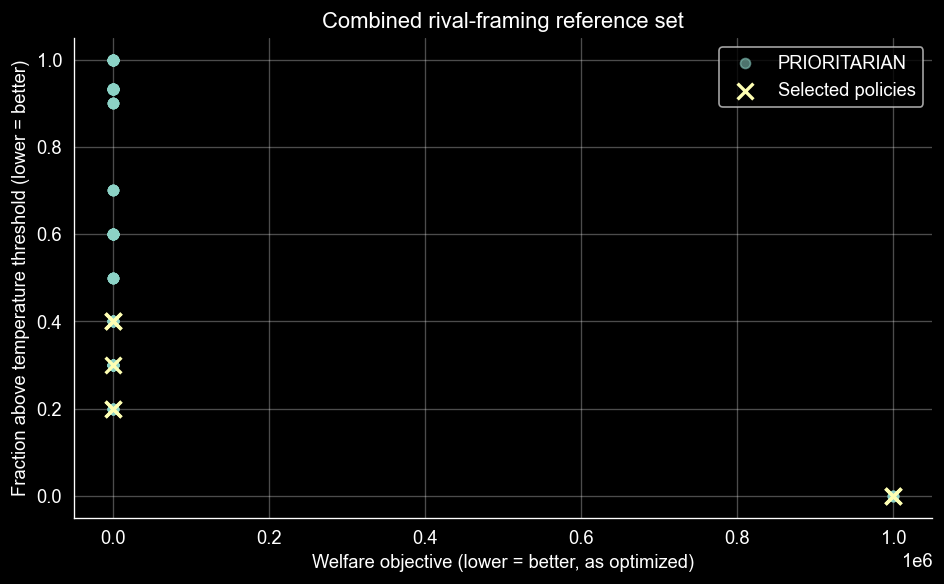

Saved figure: /Users/wesselmuntendam/Model Based Decision Making/epa141a/A- Project G15/plots/rival_framing_reference_set_welfare_vs_risk.png


In [7]:
if {"welfare", "fraction_above_threshold"}.issubset(reference_set.columns):
    fig, ax = plt.subplots(figsize=(8, 5))
    for frame, sub in reference_set.groupby("source_welfare"):
        ax.scatter(sub["welfare"], sub["fraction_above_threshold"], alpha=0.55, label=frame)

    ax.scatter(
        selected_policies["welfare"],
        selected_policies["fraction_above_threshold"],
        s=90,
        marker="x",
        linewidths=2,
        label="Selected policies",
    )
    ax.set_xlabel("Welfare objective (lower = better, as optimized)")
    ax.set_ylabel("Fraction above temperature threshold (lower = better)")
    ax.set_title("Combined rival-framing reference set")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    path = PLOTS_DIR / "rival_framing_reference_set_welfare_vs_risk.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved figure:", path)
else:
    print("Skipping plot: welfare and/or fraction_above_threshold not found.")

## 7. Re-evaluate selected policies across scenarios

This is the expensive step. For a quick test, set:

```python
RUN_REEVALUATION = True
SCENARIOS_REEVAL = [2, 3]
N_ENSEMBLES_REEVAL = 3
MAX_POLICIES_TO_REEVALUATE = 2
```

For the final run, use:

```python
RUN_REEVALUATION = True
SCENARIOS_REEVAL = list(range(8))
N_ENSEMBLES_REEVAL = 15
MAX_POLICIES_TO_REEVALUATE = None
```

In [8]:
def hard_reset_justice_singleton():
    """JUSTICE caches a singleton instance. Reset it before each run."""
    try:
        if hasattr(JUSTICE, "hard_reset"):
            JUSTICE.hard_reset()
        else:
            JUSTICE._instance = None
    except Exception:
        pass


def welfare_enum_from_name(name):
    return getattr(WelfareFunction, str(name).upper())


def get_rbf_columns(policy_row):
    rbf = RBF(n_rbfs=N_RBFS, n_inputs=N_INPUTS_RBF, n_outputs=N_REGIONS)
    c_shape, r_shape, w_shape = rbf.get_shape()
    center_cols = [f"center {i}" for i in range(c_shape[0])]
    radii_cols = [f"radii {i}" for i in range(r_shape[0])]
    weight_cols = [f"weights {i}" for i in range(w_shape[0])]
    missing = [c for c in center_cols + radii_cols + weight_cols if c not in policy_row.index]
    if missing:
        raise KeyError(f"Policy row is missing RBF columns. First missing columns: {missing[:10]}")
    return center_cols, radii_cols, weight_cols


def choose_ensemble_indices(n_ensemble):
    # Deterministic spread across available ensemble members.
    if n_ensemble <= 1:
        return [1]
    return list(np.linspace(1, 1000, n_ensemble, dtype=int))


def run_policy_with_justice(policy_row, welfare_name, scenario, n_ensemble=15):
    """Reconstruct RBF policy, run JUSTICE for one scenario, and return constrained ECR and output data."""
    hard_reset_justice_singleton()

    rbf = RBF(n_rbfs=N_RBFS, n_inputs=N_INPUTS_RBF, n_outputs=N_REGIONS)
    center_cols, radii_cols, weight_cols = get_rbf_columns(policy_row)

    centers = np.array([policy_row[c] for c in center_cols], dtype=float)
    radii = np.array([policy_row[c] for c in radii_cols], dtype=float)
    weights = np.array([policy_row[c] for c in weight_cols], dtype=float)
    rbf.set_decision_vars(np.concatenate([centers, radii, weights]))

    constraint = EmissionControlConstraint(
        max_annual_growth_rate=0.04,
        emission_control_start_timestep=EC_START_TS,
        min_emission_control_rate=0.01,
    )

    ensemble_indices = choose_ensemble_indices(n_ensemble)
    welfare_enum = welfare_enum_from_name(welfare_name)

    model = JUSTICE(
        scenario=int(scenario),
        climate_ensembles=ensemble_indices,
        economy_type=Economy.NEOCLASSICAL,
        damage_function_type=DamageFunction.KALKUHL,
        abatement_type=Abatement.ENERDATA,
        social_welfare_function=welfare_enum,
    )

    no_ens = model.no_of_ensembles
    ecr = np.zeros((N_REGIONS, N_TIMESTEPS, no_ens))
    constrained_ecr = np.zeros_like(ecr)

    prev_temp = 0.0
    diff = 0.0

    for t in range(N_TIMESTEPS):
        constrained_ecr[:, t, :] = constraint.constrain_emission_control_rate(
            ecr[:, t, :],
            t,
            allow_fallback=False,
        )

        model.stepwise_run(
            emission_control_rate=constrained_ecr[:, t, :],
            timestep=t,
            endogenous_savings_rate=True,
        )

        data = model.stepwise_evaluate(timestep=t)
        temp = data["global_temperature"][t, :]

        if t % 5 == 0:
            diff = temp - prev_temp
            prev_temp = temp

        scaled_temp = (temp - MIN_TEMP) / (MAX_TEMP - MIN_TEMP)
        scaled_diff = (diff - MIN_DIFF) / (MAX_DIFF - MIN_DIFF)

        if t < N_TIMESTEPS - 1:
            ecr[:, t + 1, :] = rbf.apply_rbfs(np.array([scaled_temp, scaled_diff]))

    datasets = model.evaluate()
    ecr_mean = constrained_ecr.mean(axis=2)
    return ecr_mean, datasets, model


def safe_divide(num, den):
    return np.divide(num, den, out=np.full_like(num, np.nan, dtype=float), where=den != 0)


def year_to_index(year):
    return time_horizon.year_to_timestep(year=int(year), timestep=cfg["timestep"])


def summarize_run(label, row, scenario, ecr_mean, data, model):
    z = ZAF_INDEX
    gross = data["gross_economic_output"][z, :, :]
    abate = data["abatement_cost"][z, :, :]
    damage = data["economic_damage"][z, :, :]
    cons_pc = data["consumption_per_capita"][z, :, :]
    temp = data["global_temperature"]

    abatement_burden = safe_divide(abate, gross)
    damage_burden = safe_divide(damage, gross)
    total_burden = safe_divide(abate + damage, gross)

    result = {
        "label": label,
        "selected_policy_id": int(row["selected_policy_id"]),
        "selected_label": row["selected_label"],
        "source_welfare": row["source_welfare"],
        "selection_type": row["selection_type"],
        "scenario": int(scenario),
        "n_ensembles": int(temp.shape[1]),
        "zaf_mean_abatement_burden_all_years": float(np.nanmean(abatement_burden)),
        "zaf_worst_abatement_burden_all_years": float(np.nanmax(abatement_burden)),
        "zaf_mean_damage_burden_all_years": float(np.nanmean(damage_burden)),
        "zaf_worst_damage_burden_all_years": float(np.nanmax(damage_burden)),
        "zaf_mean_total_burden_all_years": float(np.nanmean(total_burden)),
        "zaf_worst_total_burden_all_years": float(np.nanmax(total_burden)),
        "zaf_mean_consumption_per_capita_all_years": float(np.nanmean(cons_pc)),
        "zaf_ecr_mean_end": float(np.nanmean(ecr_mean[z, -1])),
        "global_temp_mean_2100": float(np.nanmean(temp[TEMP_YEAR_INDEX, :])),
        "global_temp_p95_2100": float(np.nanpercentile(temp[TEMP_YEAR_INDEX, :], 95)),
        "fraction_above_threshold_2100": float(np.mean(temp[TEMP_YEAR_INDEX, :] > TEMPERATURE_THRESHOLD)),
        "mean_years_above_threshold": float(np.mean(np.sum(temp > TEMPERATURE_THRESHOLD, axis=0))),
        "evaluated_welfare": float(np.ravel(data.get("welfare", [np.nan]))[0]),
    }

    for year in YEARS_OF_INTEREST:
        t = year_to_index(year)
        result[f"zaf_abatement_burden_{year}"] = float(np.nanmean(abatement_burden[t, :]))
        result[f"zaf_damage_burden_{year}"] = float(np.nanmean(damage_burden[t, :]))
        result[f"zaf_total_burden_{year}"] = float(np.nanmean(total_burden[t, :]))
        result[f"zaf_consumption_pc_{year}"] = float(np.nanmean(cons_pc[t, :]))
        result[f"zaf_ecr_{year}"] = float(ecr_mean[z, t])
        result[f"global_temp_mean_{year}"] = float(np.nanmean(temp[t, :]))

    return result

reevaluation_outputs = {}
reevaluation_rows = []

if RUN_REEVALUATION:
    to_eval = selected_policies.copy()
    if MAX_POLICIES_TO_REEVALUATE is not None:
        to_eval = to_eval.head(int(MAX_POLICIES_TO_REEVALUATE)).copy()

    print(f"Re-evaluating {len(to_eval)} selected policies across {len(SCENARIOS_REEVAL)} scenario(s).")
    print(f"Climate ensemble members per run: {N_ENSEMBLES_REEVAL}")

    for _, row in to_eval.iterrows():
        for scenario in SCENARIOS_REEVAL:
            label = f"{row['selected_label']}__scenario_{scenario}"
            print(f"Running {label} ...")
            ecr_mean, data, model = run_policy_with_justice(
                row,
                welfare_name=row["source_welfare"],
                scenario=scenario,
                n_ensemble=N_ENSEMBLES_REEVAL,
            )
            reevaluation_outputs[label] = {
                "ecr": ecr_mean,
                "data": data,
                "model": model,
                "policy_row": row.to_dict(),
                "scenario": int(scenario),
            }
            reevaluation_rows.append(summarize_run(label, row, scenario, ecr_mean, data, model))

    reevaluation_summary = pd.DataFrame(reevaluation_rows)
    reevaluation_summary.to_csv(TABLES_DIR / "rival_framing_scenario_reevaluation_summary.csv", index=False)
    reevaluation_summary.to_latex(TABLES_DIR / "rival_framing_scenario_reevaluation_summary.tex", index=False)
    print("Done. Saved scenario re-evaluation summary.")
    display(reevaluation_summary.head())
else:
    reevaluation_summary = pd.DataFrame()
    print("RUN_REEVALUATION is False. Set it to True to compute scenario stress-test outputs.")

Re-evaluating 9 selected policies across 8 scenario(s).
Climate ensemble members per run: 15
Running P0_PRIORITARIAN_best_welfare_within_frame__scenario_0 ...
Running P0_PRIORITARIAN_best_welfare_within_frame__scenario_1 ...
Running P0_PRIORITARIAN_best_welfare_within_frame__scenario_2 ...
Running P0_PRIORITARIAN_best_welfare_within_frame__scenario_3 ...
Running P0_PRIORITARIAN_best_welfare_within_frame__scenario_4 ...
Running P0_PRIORITARIAN_best_welfare_within_frame__scenario_5 ...
Running P0_PRIORITARIAN_best_welfare_within_frame__scenario_6 ...
Running P0_PRIORITARIAN_best_welfare_within_frame__scenario_7 ...
Running P1_PRIORITARIAN_best_welfare_within_frame__scenario_0 ...
Running P1_PRIORITARIAN_best_welfare_within_frame__scenario_1 ...
Running P1_PRIORITARIAN_best_welfare_within_frame__scenario_2 ...
Running P1_PRIORITARIAN_best_welfare_within_frame__scenario_3 ...
Running P1_PRIORITARIAN_best_welfare_within_frame__scenario_4 ...
Running P1_PRIORITARIAN_best_welfare_within_frame

,label,selected_policy_id,selected_label,source_welfare,selection_type,scenario,n_ensembles,zaf_mean_abatement_burden_all_years,zaf_worst_abatement_burden_all_years,zaf_mean_damage_burden_all_years,...,zaf_damage_burden_2050,zaf_total_burden_2050,zaf_consumption_pc_2050,zaf_ecr_2050,global_temp_mean_2050,zaf_abatement_burden_2100,zaf_damage_burden_2100,zaf_total_burden_2100,zaf_consumption_pc_2100,zaf_ecr_2100
0,P0_PRIORITARIAN_best_welfare_within_frame__sce...,0,P0_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,0,15,0.004193,0.094050,0.014680,...,0.013653,0.046469,20.827829,0.737254,1.668676,0.002546,0.013757,0.016303,50.222549,0.841561
1,P0_PRIORITARIAN_best_welfare_within_frame__sce...,0,P0_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,1,15,0.004179,0.075602,0.014702,...,0.013815,0.045734,20.848374,0.738559,1.677398,0.002602,0.014019,0.016622,50.197376,0.849259
2,P0_PRIORITARIAN_best_welfare_within_frame__sce...,0,P0_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,2,15,0.007301,0.108804,0.018988,...,0.015861,0.063068,16.382154,0.786943,1.775980,0.006033,0.020956,0.026989,45.486335,0.962556
3,P0_PRIORITARIAN_best_welfare_within_frame__sce...,0,P0_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,3,15,0.010408,0.138355,0.030422,...,0.015562,0.069326,11.617588,0.770316,1.764338,0.011211,0.028380,0.039591,21.679880,0.984835
4,P0_PRIORITARIAN_best_welfare_within_frame__sce...,0,P0_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,4,15,0.009426,0.128173,0.022452,...,0.014719,0.062755,16.148429,0.742591,1.725600,0.010805,0.022950,0.033755,44.562807,0.966493


## 8. Robustness summary across scenarios

This compresses the scenario re-evaluation results into one row per selected policy.

In [9]:
if reevaluation_summary.empty:
    print("No re-evaluation summary available yet. Run Section 7 with RUN_REEVALUATION = True.")
else:
    group_cols = ["selected_policy_id", "selected_label", "source_welfare", "selection_type"]
    robustness_summary = reevaluation_summary.groupby(group_cols).agg(
        n_scenarios=("scenario", "nunique"),
        mean_zaf_total_burden=("zaf_mean_total_burden_all_years", "mean"),
        worst_zaf_total_burden=("zaf_worst_total_burden_all_years", "max"),
        mean_zaf_abatement_burden=("zaf_mean_abatement_burden_all_years", "mean"),
        worst_zaf_abatement_burden=("zaf_worst_abatement_burden_all_years", "max"),
        mean_zaf_damage_burden=("zaf_mean_damage_burden_all_years", "mean"),
        worst_zaf_damage_burden=("zaf_worst_damage_burden_all_years", "max"),
        mean_fraction_above_threshold=("fraction_above_threshold_2100", "mean"),
        worst_fraction_above_threshold=("fraction_above_threshold_2100", "max"),
        mean_temp_2100=("global_temp_mean_2100", "mean"),
        worst_temp_2100=("global_temp_p95_2100", "max"),
        mean_welfare=("evaluated_welfare", "mean"),
    ).reset_index()

    robustness_summary.to_csv(TABLES_DIR / "robustness_outcomes_selected_policies.csv", index=False)
    robustness_summary.to_latex(TABLES_DIR / "robustness_outcomes_selected_policies.tex", index=False)
    display(robustness_summary)
    print("Saved robustness summary tables.")

,selected_policy_id,selected_label,source_welfare,selection_type,n_scenarios,mean_zaf_total_burden,worst_zaf_total_burden,mean_zaf_abatement_burden,worst_zaf_abatement_burden,mean_zaf_damage_burden,worst_zaf_damage_burden,mean_fraction_above_threshold,worst_fraction_above_threshold,mean_temp_2100,worst_temp_2100,mean_welfare
0,0,P0_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,8,0.030409,0.166915,8.567334e-03,0.145187,0.021842,0.076855,0.650000,0.933333,2.140885,3.004776,-432.195264
1,1,P1_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,8,0.034651,0.165412,1.190627e-02,0.145859,0.022744,0.086322,0.658333,0.933333,2.159911,3.152441,-432.220840
2,2,P2_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,8,0.030678,0.164346,8.471895e-03,0.142569,0.022206,0.077628,0.683333,0.933333,2.154415,3.034846,-432.224166
3,3,P3_PRIORITARIAN_lowest_climate_risk,PRIORITARIAN,lowest_climate_risk,8,0.069608,0.268407,4.358779e-07,0.000008,0.069608,0.268405,0.966667,1.000000,3.267617,4.985464,-435.395787
4,4,P4_PRIORITARIAN_lowest_climate_risk,PRIORITARIAN,lowest_climate_risk,8,0.059933,0.234298,6.405708e-04,0.007031,0.059293,0.234289,0.966667,1.000000,2.990270,4.547857,-434.459764
5,5,P5_PRIORITARIAN_lowest_climate_risk,PRIORITARIAN,lowest_climate_risk,8,0.068302,0.271991,1.869822e-06,0.000069,0.068300,0.271991,0.966667,1.000000,3.212549,4.921149,-435.270264
6,6,P6_PRIORITARIAN_compromise,PRIORITARIAN,compromise,8,0.047335,0.169998,1.235463e-02,0.154006,0.034980,0.134221,0.766667,1.000000,2.322603,3.400705,-432.742512
7,7,P7_PRIORITARIAN_compromise,PRIORITARIAN,compromise,8,0.047706,0.175212,1.301799e-02,0.157280,0.034688,0.128550,0.766667,1.000000,2.313588,3.368676,-432.746060
8,8,P8_PRIORITARIAN_compromise,PRIORITARIAN,compromise,8,0.034659,0.126534,4.283204e-04,0.011668,0.034231,0.126511,0.766667,1.000000,2.319643,3.399199,-432.663994


Saved robustness summary tables.


## 9. South Africa burden comparison by policy and scenario

In [10]:
if reevaluation_summary.empty:
    print("No re-evaluation summary available yet. Run Section 7 first.")
else:
    burden_cols = [
        "selected_label", "source_welfare", "selection_type", "scenario",
        "zaf_mean_abatement_burden_all_years", "zaf_worst_abatement_burden_all_years",
        "zaf_mean_damage_burden_all_years", "zaf_worst_damage_burden_all_years",
        "zaf_mean_total_burden_all_years", "zaf_worst_total_burden_all_years",
    ]
    for year in YEARS_OF_INTEREST:
        burden_cols += [
            f"zaf_abatement_burden_{year}",
            f"zaf_damage_burden_{year}",
            f"zaf_total_burden_{year}",
            f"zaf_ecr_{year}",
        ]
    burden_cols = [c for c in burden_cols if c in reevaluation_summary.columns]
    south_africa_burden = reevaluation_summary[burden_cols].copy()

    south_africa_burden.to_csv(TABLES_DIR / "south_africa_burden_comparison_by_scenario.csv", index=False)
    south_africa_burden.to_latex(TABLES_DIR / "south_africa_burden_comparison_by_scenario.tex", index=False)
    display(south_africa_burden.head(20))
    print("Saved South Africa burden comparison tables.")

,selected_label,source_welfare,selection_type,scenario,zaf_mean_abatement_burden_all_years,zaf_worst_abatement_burden_all_years,zaf_mean_damage_burden_all_years,zaf_worst_damage_burden_all_years,zaf_mean_total_burden_all_years,zaf_worst_total_burden_all_years,zaf_abatement_burden_2050,zaf_damage_burden_2050,zaf_total_burden_2050,zaf_ecr_2050,zaf_abatement_burden_2100,zaf_damage_burden_2100,zaf_total_burden_2100,zaf_ecr_2100
0,P0_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,0,0.004193,0.094050,0.014680,0.053114,0.018873,0.116699,0.032817,0.013653,0.046469,0.737254,0.002546,0.013757,0.016303,0.841561
1,P0_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,1,0.004179,0.075602,0.014702,0.052837,0.018881,0.097324,0.031920,0.013815,0.045734,0.738559,0.002602,0.014019,0.016622,0.849259
2,P0_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,2,0.007301,0.108804,0.018988,0.055702,0.026289,0.129940,0.047207,0.015861,0.063068,0.786943,0.006033,0.020956,0.026989,0.962556
3,P0_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,3,0.010408,0.138355,0.030422,0.076855,0.040829,0.159960,0.053764,0.015562,0.069326,0.770316,0.011211,0.028380,0.039591,0.984835
4,P0_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,4,0.009426,0.128173,0.022452,0.064738,0.031877,0.148000,0.048037,0.014719,0.062755,0.742591,0.010805,0.022950,0.033755,0.966493
5,P0_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,5,0.010834,0.145187,0.024097,0.066483,0.034930,0.166915,0.060987,0.016036,0.077023,0.784146,0.011077,0.025333,0.036411,0.974819
6,P0_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,6,0.010998,0.134813,0.019434,0.057703,0.030433,0.151776,0.084980,0.020387,0.105366,0.875061,0.008188,0.019201,0.027389,0.962176
7,P0_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,7,0.011200,0.134768,0.029961,0.069904,0.041162,0.150822,0.085181,0.020675,0.105856,0.875493,0.008432,0.032917,0.041349,0.971706
8,P1_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,0,0.007883,0.097582,0.014774,0.052929,0.022658,0.120222,0.076868,0.013741,0.090608,0.928541,0.003729,0.013960,0.017689,0.956741
9,P1_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,1,0.007927,0.097677,0.014776,0.052622,0.022703,0.118928,0.077382,0.013908,0.091290,0.929910,0.003744,0.014190,0.017935,0.957569


Saved South Africa burden comparison tables.


## 10. Regional comparison: South Africa vs other regions

This computes regional burden metrics for the first available re-evaluated result for each selected policy. It is mainly for the report table comparing South Africa with rich countries / large emitters.

In [11]:
def region_burden_rows_from_output(output_label, output, regions=COMPARE_REGIONS):
    data = output["data"]
    ecr = output["ecr"]
    scenario = output["scenario"]
    policy_row = output["policy_row"]
    rows = []
    for region in regions:
        if region not in REGION_LIST:
            continue
        idx = REGION_LIST.index(region)
        gross = data["gross_economic_output"][idx, :, :]
        abate = data["abatement_cost"][idx, :, :]
        damage = data["economic_damage"][idx, :, :]
        total = abate + damage
        abatement_burden = safe_divide(abate, gross)
        damage_burden = safe_divide(damage, gross)
        total_burden = safe_divide(total, gross)
        row = {
            "label": output_label,
            "selected_label": policy_row.get("selected_label"),
            "source_welfare": policy_row.get("source_welfare"),
            "selection_type": policy_row.get("selection_type"),
            "scenario": scenario,
            "region": region,
            "mean_abatement_burden": float(np.nanmean(abatement_burden)),
            "mean_damage_burden": float(np.nanmean(damage_burden)),
            "mean_total_burden": float(np.nanmean(total_burden)),
            "worst_total_burden": float(np.nanmax(total_burden)),
            "ecr_end": float(ecr[idx, -1]),
        }
        for year in YEARS_OF_INTEREST:
            t = year_to_index(year)
            row[f"abatement_burden_{year}"] = float(np.nanmean(abatement_burden[t, :]))
            row[f"damage_burden_{year}"] = float(np.nanmean(damage_burden[t, :]))
            row[f"total_burden_{year}"] = float(np.nanmean(total_burden[t, :]))
            row[f"ecr_{year}"] = float(ecr[idx, t])
        rows.append(row)
    return rows

if not reevaluation_outputs:
    print("No re-evaluation outputs available yet. Run Section 7 first.")
else:
    regional_rows = []
    # Use all outputs. If this is too large, filter to scenario == REFERENCE_SCENARIO.
    for label, output in reevaluation_outputs.items():
        regional_rows.extend(region_burden_rows_from_output(label, output))

    regional_burden = pd.DataFrame(regional_rows)
    regional_burden.to_csv(TABLES_DIR / "regional_burden_comparison_selected_policies.csv", index=False)
    regional_burden.to_latex(TABLES_DIR / "regional_burden_comparison_selected_policies.tex", index=False)
    display(regional_burden.head(30))
    print("Saved regional burden comparison tables.")

,label,selected_label,source_welfare,selection_type,scenario,region,mean_abatement_burden,mean_damage_burden,mean_total_burden,worst_total_burden,ecr_end,abatement_burden_2050,damage_burden_2050,total_burden_2050,ecr_2050,abatement_burden_2100,damage_burden_2100,total_burden_2100,ecr_2100
0,P0_PRIORITARIAN_best_welfare_within_frame__sce...,P0_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,0,zaf,0.004193,0.014680,0.018873,0.116699,0.926703,0.032817,0.013653,0.046469,0.737254,0.002546,0.013757,0.016303,0.841561
1,P0_PRIORITARIAN_best_welfare_within_frame__sce...,P0_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,0,usa,0.008167,0.010247,0.018415,0.096033,0.997967,0.052504,0.010877,0.063381,0.989513,0.013605,0.009735,0.023339,0.997741
2,P0_PRIORITARIAN_best_welfare_within_frame__sce...,P0_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,0,gbr,0.005066,0.004416,0.009482,0.039930,0.980533,0.024622,0.004733,0.029355,0.914365,0.009350,0.004346,0.013696,0.953093
3,P0_PRIORITARIAN_best_welfare_within_frame__sce...,P0_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,0,fra,0.005793,0.006932,0.012725,0.047945,0.985856,0.023360,0.007330,0.030690,0.932718,0.012410,0.006692,0.019102,0.964224
4,P0_PRIORITARIAN_best_welfare_within_frame__sce...,P0_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,0,rfa,0.014290,0.004274,0.018564,0.111383,0.975518,0.070724,0.005383,0.076107,0.898636,0.028920,0.004264,0.033183,0.942608
5,P0_PRIORITARIAN_best_welfare_within_frame__sce...,P0_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,0,pol,0.004833,0.004133,0.008966,0.060733,0.968210,0.022205,0.005866,0.028071,0.868281,0.009358,0.004141,0.013499,0.923086
6,P0_PRIORITARIAN_best_welfare_within_frame__sce...,P0_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,0,chn,0.003898,0.008983,0.012881,0.061242,0.989747,0.035574,0.009127,0.044701,0.972980,0.003323,0.008573,0.011896,0.985472
7,P0_PRIORITARIAN_best_welfare_within_frame__sce...,P0_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,0,rus,0.008167,-0.002566,0.005601,0.124918,0.983307,0.049139,0.002258,0.051398,0.941939,0.014115,-0.002109,0.012006,0.967685
8,P0_PRIORITARIAN_best_welfare_within_frame__sce...,P0_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,1,zaf,0.004179,0.014702,0.018881,0.097324,0.929099,0.031920,0.013815,0.045734,0.738559,0.002602,0.014019,0.016622,0.849259
9,P0_PRIORITARIAN_best_welfare_within_frame__sce...,P0_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,1,usa,0.008169,0.010264,0.018432,0.095876,0.997963,0.052454,0.010985,0.063439,0.989300,0.013607,0.009933,0.023540,0.997759


Saved regional burden comparison tables.


## 11. Rival welfare comparison table for Chapter 4

This table compares policies selected from prioritarian and utilitarian sources after scenario stress-testing.

In [12]:
if reevaluation_summary.empty:
    # Create a preliminary table from the reference set only.
    preliminary_cols = [
        "selected_label", "source_welfare", "selection_type", "reference_set_id"
    ] + OBJECTIVE_COLS
    preliminary_cols = [c for c in preliminary_cols if c in selected_policies.columns]
    rival_welfare_comparison = selected_policies[preliminary_cols].copy()
    rival_welfare_comparison["table_status"] = "preliminary_reference_set_only"
else:
    rival_welfare_comparison = robustness_summary.copy()
    rival_welfare_comparison["table_status"] = "scenario_reevaluated"

rival_welfare_comparison.to_csv(TABLES_DIR / "rival_welfare_comparison_zaf.csv", index=False)
rival_welfare_comparison.to_latex(TABLES_DIR / "rival_welfare_comparison_zaf.tex", index=False)
display(rival_welfare_comparison)
print("Saved rival welfare comparison table.")

,selected_policy_id,selected_label,source_welfare,selection_type,n_scenarios,mean_zaf_total_burden,worst_zaf_total_burden,mean_zaf_abatement_burden,worst_zaf_abatement_burden,mean_zaf_damage_burden,worst_zaf_damage_burden,mean_fraction_above_threshold,worst_fraction_above_threshold,mean_temp_2100,worst_temp_2100,mean_welfare,table_status
0,0,P0_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,8,0.030409,0.166915,8.567334e-03,0.145187,0.021842,0.076855,0.650000,0.933333,2.140885,3.004776,-432.195264,scenario_reevaluated
1,1,P1_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,8,0.034651,0.165412,1.190627e-02,0.145859,0.022744,0.086322,0.658333,0.933333,2.159911,3.152441,-432.220840,scenario_reevaluated
2,2,P2_PRIORITARIAN_best_welfare_within_frame,PRIORITARIAN,best_welfare_within_frame,8,0.030678,0.164346,8.471895e-03,0.142569,0.022206,0.077628,0.683333,0.933333,2.154415,3.034846,-432.224166,scenario_reevaluated
3,3,P3_PRIORITARIAN_lowest_climate_risk,PRIORITARIAN,lowest_climate_risk,8,0.069608,0.268407,4.358779e-07,0.000008,0.069608,0.268405,0.966667,1.000000,3.267617,4.985464,-435.395787,scenario_reevaluated
4,4,P4_PRIORITARIAN_lowest_climate_risk,PRIORITARIAN,lowest_climate_risk,8,0.059933,0.234298,6.405708e-04,0.007031,0.059293,0.234289,0.966667,1.000000,2.990270,4.547857,-434.459764,scenario_reevaluated
5,5,P5_PRIORITARIAN_lowest_climate_risk,PRIORITARIAN,lowest_climate_risk,8,0.068302,0.271991,1.869822e-06,0.000069,0.068300,0.271991,0.966667,1.000000,3.212549,4.921149,-435.270264,scenario_reevaluated
6,6,P6_PRIORITARIAN_compromise,PRIORITARIAN,compromise,8,0.047335,0.169998,1.235463e-02,0.154006,0.034980,0.134221,0.766667,1.000000,2.322603,3.400705,-432.742512,scenario_reevaluated
7,7,P7_PRIORITARIAN_compromise,PRIORITARIAN,compromise,8,0.047706,0.175212,1.301799e-02,0.157280,0.034688,0.128550,0.766667,1.000000,2.313588,3.368676,-432.746060,scenario_reevaluated
8,8,P8_PRIORITARIAN_compromise,PRIORITARIAN,compromise,8,0.034659,0.126534,4.283204e-04,0.011668,0.034231,0.126511,0.766667,1.000000,2.319643,3.399199,-432.663994,scenario_reevaluated


Saved rival welfare comparison table.


## 12. Debate claims from the model

This converts the tables into short claims you can use in the report or debate. Update the wording after inspecting the actual numbers.

In [13]:
claims = [
    {
        "claim": "A combined reference set was constructed from Pareto-optimal policies generated under prioritarian and utilitarian welfare framings.",
        "model_evidence": "reference_set_rival_framing_combined.csv",
        "political_use": "Shows that the rival-framing comparison is based on a shared candidate pool, not cherry-picked single policies.",
    },
    {
        "claim": "Prioritarian policies make South Africa's proportional burden more visible than a purely global efficiency frame.",
        "model_evidence": "south_africa_burden_comparison_by_scenario.csv; rival_welfare_comparison_zaf.csv",
        "political_use": "Supports the argument that equal mitigation obligations can be unfair without transition finance.",
    },
    {
        "claim": "Climate ambition and fairness should be assessed together: low climate-risk policies can still create high transition burdens for coal-dependent economies.",
        "model_evidence": "robustness_outcomes_selected_policies.csv; regional_burden_comparison_selected_policies.csv",
        "political_use": "Frames South Africa as pro-ambition but conditional on a funded Just Transition.",
    },
    {
        "claim": "Scenario re-evaluation tests whether South Africa's burden argument holds beyond the reference scenario.",
        "model_evidence": "rival_framing_scenario_reevaluation_summary.csv",
        "political_use": "Links the rival-framing section to robustness and deep uncertainty.",
    },
]

debate_claims = pd.DataFrame(claims)
debate_claims.to_csv(TABLES_DIR / "debate_claims_from_model.csv", index=False)
debate_claims.to_latex(TABLES_DIR / "debate_claims_from_model.tex", index=False)
display(debate_claims)
print("Saved debate claim table.")

,claim,model_evidence,political_use
0,A combined reference set was constructed from ...,reference_set_rival_framing_combined.csv,Shows that the rival-framing comparison is bas...
1,Prioritarian policies make South Africa's prop...,south_africa_burden_comparison_by_scenario.csv...,Supports the argument that equal mitigation ob...
2,Climate ambition and fairness should be assess...,robustness_outcomes_selected_policies.csv; reg...,Frames South Africa as pro-ambition but condit...
3,Scenario re-evaluation tests whether South Afr...,rival_framing_scenario_reevaluation_summary.csv,Links the rival-framing section to robustness ...


Saved debate claim table.


## 13. Checklist before using results in the report

Use this checklist before copying numbers into Chapter 4:

1. Check that both `PRIORITARIAN` and `UTILITARIAN` appear in the candidate pool.
2. Check that the combined reference set is not empty.
3. Check that selected policies include both welfare framings and low-climate-risk policies.
4. Run a quick re-evaluation first with 2 policies, 2 scenarios, and 3 ensembles.
5. Run the final re-evaluation with all selected policies, 8 scenarios, and 15 ensembles.
6. Use `south_africa_burden_comparison_by_scenario.csv`, `robustness_outcomes_selected_policies.csv`, and `rival_welfare_comparison_zaf.csv` for the Results chapter.